Our stiff system is a mechanical system with high dampening

The governing ODE is: dx/dt = -(k/c)x + (1/c)F(t)
- c is the dampening coefficient
- k is the spring constant
- x is the displacement from equilibrium
- F(t) is the external force

To ensure stiffness:
- k/c = 5000 s^-1 (very high dampening)
- F(t) = 10sin(t) N (slow external force)
- Also x(0) = 1 m

This system is important in practice because it can be used to represent something such as a wall which would return to equilibrium very quickly as the dampening would be much greater than the external force typically.

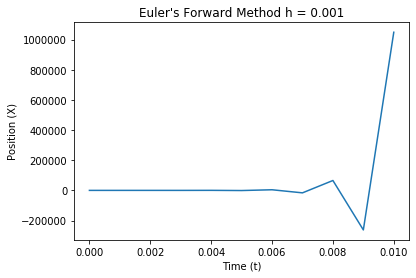

system is clearly unstable with step size 0.001


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    """
    Returns derivatives at a time and position:
    Given: time(t), postition(x)
    """
    return -5000*x +  0.002*np.sin(t)

def euler(t_start, t_end, h):
    """
    Returns Forward Euler times and postitions found:
    Given: initial time (t_start), final time (t_end), step size(h)
    """
    #establishes vectors
    num_steps = int((t_end - t_start) / h)
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    x_values = np.zeros(num_steps + 1)
    #initial condition
    x_values[0] = 1
    #calculates each step
    for i in range(num_steps):
        x_values[i + 1] = x_values[i] + h * f(t_values[i], x_values[i])
    return t_values, x_values

#establishing problem barriers
h = 0.001
t0 = 0
tf = 0.01
x0 = 1
#showing forward eulers unstable
t, x = euler(t0, tf, h)
plt.plot(t, x)
plt.xlabel('Time (t)')
plt.ylabel('Position (X)')
plt.title('Euler\'s Forward Method h = 0.001')
plt.show()
print("system is clearly unstable with step size 0.001")

The stiffness ratio for this system is 5000.

Since the fast dynamics are much quicker than the slow dynamics, explicit methods require extremely small step sizes for stability. This confirms the stiffness for the system.

The step size required for Forward Euler's stability is less that 2/5000 or 0.0004. For a simulation of just 0.01 seconds, we would need 25 steps to be computed. This is also for it to remain barely stable. Our solution would definately need even more steps than this to accurately show the system, and if we wanted to see the results for a wider range of time, it only adds that much more impracticality.

Implicit methods are necessary because explicit methods are restricted by stability conditions

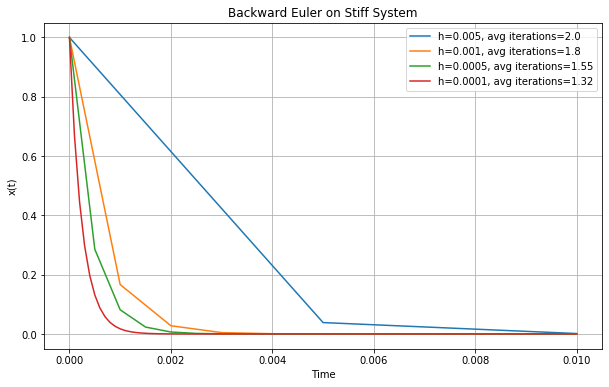

In [36]:
def backward_euler_step(x, t, h, tol=1e-6, max_iter=20):
    """
    Returns next step and number of iterations:
    Given: postion(x), time(t), step size(h)
    """
    # Initial guess
    x_next = x
    #keeps within max iterations
    for i in range(max_iter):
        g_val = x_next - x - h * f(t+h, x_next)
        g_prime_val = 1 + 5000*h
        # Avoid division by zero
        if abs(g_prime_val) < tol:
            break
        x_new = x_next - g_val / g_prime_val
        # Converged
        if abs(x_new - x_next) < tol:
            return x_new, i+1
        x_next = x_new
    return x_next, max_iter

def backward_euler(t0, tf, h, x0):
    """
    Returns Backward Euler times, postitions, average iterations per step, and the iterations each step took
    Given: initial time (t0), final time(tf), step size(h), initial position(x0)
    """
    #establishes vectors
    n = int((tf - t0)/h)
    t_vals = np.linspace(t0, tf, n+1)
    x_vals = np.zeros(n+1)
    x_vals[0] = x0
    #sets up iteration calcs
    total_iterations = 0
    iterations_per = np.zeros(n+1)
    #calculates each step
    for k in range(n):
        x_vals[k+1], iterations = backward_euler_step(x_vals[k], t_vals[k], h)
        total_iterations += iterations
        iterations_per[k] = iterations
    #averages iterations per step
    avg_iterations = total_iterations / n
    return t_vals, x_vals, avg_iterations, iterations_per

#sets step sizes
step_sizes = [0.005, 0.001, 0.0005, 0.0001]
plt.figure(figsize=(10,6))
#calculates and plots for each step size
for h in step_sizes:
    t, y, avg_iterations, _ = backward_euler(t0, tf, h, x0)
    plt.plot(t, y, label=f"h={h}, avg iterations={avg_iterations}")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Backward Euler on Stiff System")
plt.legend()
plt.grid(True)
plt.show()

While the maximum stable step size for Forward's Euler is a tiny 0.0004, Backward's Euler does not have a finite maximum stable step size. This means, for this situation, Backward's Euler will always be stable, even if relatively inaccurate, while Forward's Euler may not be.

The total number of steps for Backward's Euler ranged from 2 to 100, and remainded stable for all of them. The average number of iterations per step for Backward's Euler is also only between 1 and two depending on the step size being used for what we tested. There is only as many function evaluations as iterations, meaning there was between 4 and 132 for step sizes we tested.

For Forward's Euler with the maximum stable step size of 0.0004, it took 25 steps and therefore 25 function evaluations to cross the same time span. This step size also results in a less accurate representation of the function than Backward's Euler for the same step size, although it took a few less function evaluations. It takes far more for Forward's Euler to remain stable for this system.

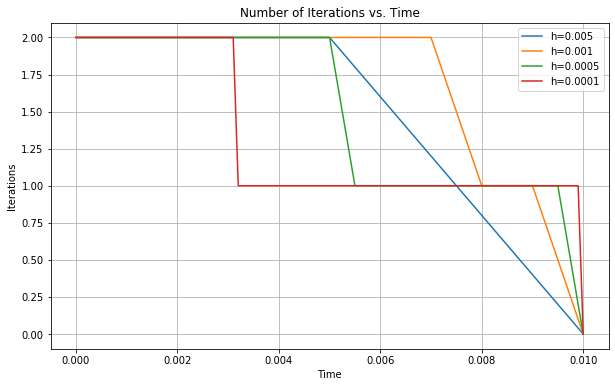

In [41]:
plt.figure(figsize=(10,6))
#calculates and plots iterations for each step size
for h in step_sizes:
    t, y, avg_iterations, iterations_per = backward_euler(t0, tf, h, x0)
    plt.plot(t, iterations_per, label=f"h={h}")
plt.xlabel("Time")
plt.ylabel("Iterations")
plt.title("Number of Iterations vs. Time")
plt.legend()
plt.grid(True)
plt.show()

The system will always converge for Backward's Euler. Smaller step sizes improve convergence stability but do not significantly change iteration count due to linearity. Using xn as the initial guess ensures near-perfect convergence because the solution changes smoothly over time. Because the system is linear in x, Newton’s method converges in essentially one iteration per step. A nonlinear system would show higher iteration counts, stronger dependence on step size, and more sensitivity to initial guess.

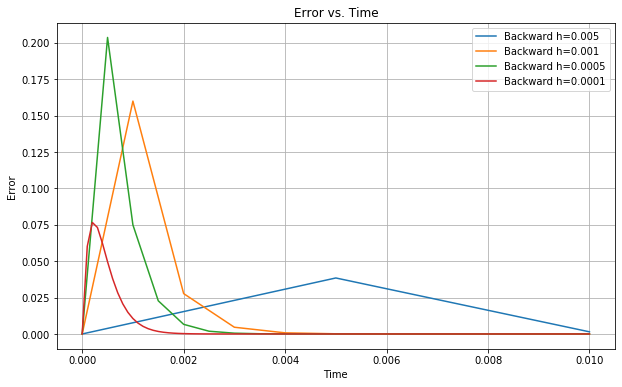

In [45]:
def exact_solution(t):
    """
    Returns exact position at a time:
    Given: time(t)
    """
    return 1*np.exp(-5000*t) + (0.002 *(5000 * np.sin(t) - np.cos(t)))/(5000**2 + 1) + (0.002 * np.exp(-5000*t)) / (5000**2 + 1)

plt.figure(figsize=(10,6))
#calculates and plots error for each step size
for h in step_sizes:
    t_b, y, avg_iterations, iterations_per = backward_euler(t0, tf, h, x0)
    error_b = np.abs(y - exact_solution(t_b))
    plt.plot(t_b, error_b, label=f"Backward h={h}")
plt.xlabel("Time")
plt.ylabel("Error")
plt.title("Error vs. Time")
plt.legend()
plt.grid(True)
plt.show()

The Backward Euler solution closely matches the reference solution, while Forward Euler accumulates significant error and may become unstable. The numerical results confirm that the fast transient decays rapidly, after which the solution follows the slow forcing dynamics. Backward Euler is physically viable, since it rapidly converges to 0, and accurately resolves both fast and slow scales, demonstrating its suitability for stiff systems.

Conclusion: Backward Euler was extremely consistent and converged for all step sizes, while Forward Euler struggled to converge for the stiff system. You should use explicit functions when it is a non-stiff system, eigenvalues are small, high accuracy is needed, and step size is not limited. You should use implicit functions when stability is the most important. I learned that it is very easy for explicit functions to not work for a system without severe step sizes, time scaling can be very important to understanding a data set.